In [ ]:
# ============================================
# PROJECT 2: CUSTOMER QUERY ANALYSIS AND NLP CHATBOT
# STEP 1: IMPORT NECESSARY LIBRARIES
# ============================================

# NumPy is used for numerical operations
import numpy as np

# Pandas is used for creating, storing and analyzing our dataset
import pandas as pd

# NLTK is a Natural Language Processing library
import nltk

# Matplotlib is used for creating graphs
import matplotlib.pyplot as plt

# Seaborn is used for data visualization
import seaborn as sns

# TfidfVectorizer converts text into numerical features
# that can be understood by a machine learning model
from sklearn.feature_extraction.text import TfidfVectorizer

# Logistic Regression will be used to classify
# customer queries into different categories
from sklearn.linear_model import LogisticRegression

# These functions are used to split the dataset
# and evaluate the trained model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# ============================================
# STEP 2: CREATE THE CHATBOT DATASET
# ============================================

# Create a dictionary containing customer queries,
# their categories, and the response the chatbot should give
chatbot_data = {

    "query": [
        # Greeting queries
        "Hello",
        "Hi",
        "Good morning",
        "Hey there",

        # Services queries
        "What services do you provide?",
        "What services are available?",
        "Tell me about your services",
        "What can you help me with?",

        # Pricing queries
        "What is the price?",
        "How much does it cost?",
        "Tell me the pricing",
        "What are your charges?",

        # Support queries
        "I need help",
        "Can you help me?",
        "I have a problem",
        "I need customer support",

        # Thanks queries
        "Thank you",
        "Thanks",
        "Thank you for your help",
        "I appreciate your help",

        # Goodbye queries
        "Bye",
        "Goodbye",
        "See you later",
        "Have a nice day"
    ],

    "category": [
        # Greeting category
        "greeting",
        "greeting",
        "greeting",
        "greeting",

        # Services category
        "services",
        "services",
        "services",
        "services",

        # Pricing category
        "pricing",
        "pricing",
        "pricing",
        "pricing",

        # Support category
        "support",
        "support",
        "support",
        "support",

        # Thanks category
        "thanks",
        "thanks",
        "thanks",
        "thanks",

        # Goodbye category
        "goodbye",
        "goodbye",
        "goodbye",
        "goodbye"
    ],

    "response": [
        # Responses for greeting
        "Hello! How can I help you?",
        "Hi! How can I help you?",
        "Good morning! How can I help you?",
        "Hello! What can I do for you?",

        # Responses for services
        "We provide customer-focused services.",
        "We offer a range of customer services.",
        "We provide different services to help our customers.",
        "I can provide information about our services.",

        # Responses for pricing
        "Please contact us for detailed pricing information.",
        "The price depends on the service you choose.",
        "Please contact us to know the current pricing.",
        "Our charges depend on the selected service.",

        # Responses for support
        "Sure! I will try to help you.",
        "Of course! Please tell me your problem.",
        "I'm sorry you are facing a problem. Please provide more details.",
        "Sure! How can I assist you?",

        # Responses for thanks
        "You're welcome!",
        "You're welcome! Happy to help.",
        "Glad I could help!",
        "You're very welcome!",

        # Responses for goodbye
        "Goodbye! Have a great day!",
        "Bye! Have a great day!",
        "See you later!",
        "Thank you for chatting with me. Goodbye!"
    ]
}

# Convert the dictionary into a Pandas DataFrame
data = pd.DataFrame(chatbot_data)

# Display the complete dataset
data

,query,category,response
0,Hello,greeting,Hello! How can I help you?
1,Hi,greeting,Hi! How can I help you?
2,Good morning,greeting,Good morning! How can I help you?
3,Hey there,greeting,Hello! What can I do for you?
4,What services do you provide?,services,We provide customer-focused services.
5,What services are available?,services,We offer a range of customer services.
6,Tell me about your services,services,We provide different services to help our cust...
7,What can you help me with?,services,I can provide information about our services.
8,What is the price?,pricing,Please contact us for detailed pricing informa...
9,How much does it cost?,pricing,The price depends on the service you choose.


In [ ]:
# ============================================
# CHECK THE CHATBOT DATASET
# ============================================

# Display the number of rows and columns
print("Dataset shape:", data.shape)

# Display the column names
print("\nColumn names:")
print(data.columns)

# Display the first 5 rows
print("\nFirst 5 rows:")
print(data.head())

Dataset shape: (24, 3)

Column names:
Index(['query', 'category', 'response'], dtype='object')

First 5 rows:
                           query  category  \
0                          Hello  greeting   
1                             Hi  greeting   
2                   Good morning  greeting   
3                      Hey there  greeting   
4  What services do you provide?  services   

                                response  
0             Hello! How can I help you?  
1                Hi! How can I help you?  
2      Good morning! How can I help you?  
3          Hello! What can I do for you?  
4  We provide customer-focused services.  


In [ ]:
# ============================================
# STEP 3.1: DATASET INFORMATION
# ============================================

# Display information about the dataset,
# including columns, number of entries and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   query     24 non-null     object
 1   category  24 non-null     object
 2   response  24 non-null     object
dtypes: object(3)
memory usage: 708.0+ bytes


In [ ]:
# ============================================
# STEP 3.2: CHECK FOR MISSING VALUES
# ============================================

# Count missing values in each column
missing_values = data.isnull().sum()

# Display the missing-value count
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
query       0
category    0
response    0
dtype: int64


In [ ]:
# ============================================
# STEP 3.3: ANALYZE CATEGORY DISTRIBUTION
# ============================================

# Count how many queries belong to each category
category_counts = data['category'].value_counts()

# Display the category counts
print("Number of queries in each category:")
print(category_counts)

Number of queries in each category:
category
greeting    4
services    4
pricing     4
support     4
thanks      4
goodbye     4
Name: count, dtype: int64


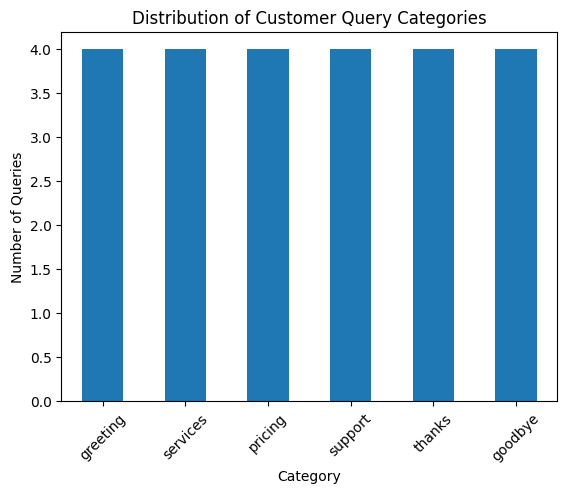

In [ ]:
# ============================================
# STEP 3.4: VISUALIZE CATEGORY DISTRIBUTION
# ============================================

# Create a bar chart showing the number of
# queries in each chatbot category
category_counts.plot(kind='bar')

# Label the X-axis
plt.xlabel("Category")

# Label the Y-axis
plt.ylabel("Number of Queries")

# Add a title to the graph
plt.title("Distribution of Customer Query Categories")

# Rotate category names slightly for readability
plt.xticks(rotation=45)

# Display the graph
plt.show()

In [ ]:
# ============================================
# STEP 4.1: PREPARE NLTK
# ============================================

# Download the basic NLTK data package
# required for Natural Language Processing
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# ============================================
# STEP 4.2: TEXT PREPROCESSING
# ============================================

# Import Python's regular expression library
# to help remove unwanted characters
import re

# Create a function to preprocess customer queries
def preprocess_text(text):

    # Convert all characters to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    # while keeping letters, numbers and spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Remove extra spaces from the beginning
    # and end of the text
    text = text.strip()

    # Return the cleaned text
    return text


# Apply the preprocessing function to every query
data['cleaned_query'] = data['query'].apply(preprocess_text)

# Display the original and cleaned queries
data[['query', 'cleaned_query']].head(10)

,query,cleaned_query
0,Hello,hello
1,Hi,hi
2,Good morning,good morning
3,Hey there,hey there
4,What services do you provide?,what services do you provide
5,What services are available?,what services are available
6,Tell me about your services,tell me about your services
7,What can you help me with?,what can you help me with
8,What is the price?,what is the price
9,How much does it cost?,how much does it cost


In [ ]:
# ============================================
# STEP 5.1: CONVERT TEXT INTO NUMERICAL FEATURES
# ============================================

# Create a TF-IDF vectorizer
# This converts text into numerical feature values
vectorizer = TfidfVectorizer()

# Convert the cleaned customer queries into
# a numerical TF-IDF matrix
X = vectorizer.fit_transform(data['cleaned_query'])

# Store the categories as our target variable
y = data['category']

# Display the shape of the TF-IDF matrix
print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (24, 45)


In [ ]:
# ============================================
# STEP 5.2: VIEW THE LEARNED VOCABULARY
# ============================================

# Get all words learned by the TF-IDF vectorizer
feature_names = vectorizer.get_feature_names_out()

# Display the vocabulary
print("Words learned by the TF-IDF vectorizer:")
print(feature_names)

Words learned by the TF-IDF vectorizer:
['about' 'appreciate' 'are' 'available' 'bye' 'can' 'charges' 'cost'
 'customer' 'day' 'do' 'does' 'for' 'good' 'goodbye' 'have' 'hello' 'help'
 'hey' 'hi' 'how' 'is' 'it' 'later' 'me' 'morning' 'much' 'need' 'nice'
 'price' 'pricing' 'problem' 'provide' 'see' 'services' 'support' 'tell'
 'thank' 'thanks' 'the' 'there' 'what' 'with' 'you' 'your']


In [ ]:
# ============================================
# STEP 5.3: VIEW TF-IDF FEATURES
# ============================================

# Convert the TF-IDF matrix into a normal DataFrame
# so that we can easily view the numerical values
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=feature_names
)

# Display the first 5 rows
tfidf_df.head()

,about,appreciate,are,available,bye,can,charges,cost,customer,day,...,support,tell,thank,thanks,the,there,what,with,you,your
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.707107,0.000000,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.366142,0.0,0.342887,0.0


In [ ]:
# ============================================
# STEP 6: SPLIT DATA INTO TRAINING AND TESTING
# ============================================

# Split the TF-IDF features and target categories
# into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,                       # TF-IDF feature data
    y,                       # Target categories
    test_size=0.25,          # 25% of data will be used for testing
    random_state=42,         # Makes the split reproducible
    stratify=y               # Keeps all categories represented
)

# Display the size of each dataset
print("Training data size:", X_train.shape[0])
print("Testing data size:", X_test.shape[0])

Training data size: 18
Testing data size: 6


In [ ]:
# ============================================
# CHECK TRAINING AND TESTING CATEGORIES
# ============================================

# Display the categories used for training
print("Training categories:")
print(y_train.value_counts())

# Display the categories used for testing
print("\nTesting categories:")
print(y_test.value_counts())


Training categories:
category
thanks      3
pricing     3
goodbye     3
services    3
greeting    3
support     3
Name: count, dtype: int64

Testing categories:
category
goodbye     1
thanks      1
pricing     1
support     1
services    1
greeting    1
Name: count, dtype: int64


In [ ]:
# ============================================
# STEP 7: TRAIN THE CLASSIFICATION MODEL
# ============================================

# Create a Logistic Regression classification model
# The model will learn to classify queries into categories
model = LogisticRegression(
    max_iter=1000
)

# Train the model using the training data
# X_train contains the TF-IDF features
# y_train contains the correct categories
model.fit(X_train, y_train)

# Display a message after successful training
print("Chatbot classification model trained successfully!")

Chatbot classification model trained successfully!


In [ ]:
# ============================================
# STEP 7.2: MAKE PREDICTIONS ON TEST DATA
# ============================================

# Use the trained model to predict categories
# for the unseen testing queries
y_pred = model.predict(X_test)

# Display the actual categories
print("Actual Categories:")
print(y_test.values)

# Display the categories predicted by the model
print("\nPredicted Categories:")
print(y_pred)

Actual Categories:
['goodbye' 'thanks' 'pricing' 'support' 'services' 'greeting']

Predicted Categories:
['thanks' 'support' 'pricing' 'support' 'services' 'greeting']


In [ ]:
# ============================================
# STEP 7.3: COMPARE ACTUAL AND PREDICTED VALUES
# ============================================

# Create a DataFrame to compare the actual
# category with the model's predicted category
comparison = pd.DataFrame({
    "Actual Category": y_test.values,
    "Predicted Category": y_pred
})

# Display the comparison table
comparison

,Actual Category,Predicted Category
0,goodbye,thanks
1,thanks,support
2,pricing,pricing
3,support,support
4,services,services
5,greeting,greeting


In [ ]:
# ============================================
# STEP 8.1: CALCULATE MODEL ACCURACY
# ============================================

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy
print("Model Accuracy:", accuracy)

# Display accuracy as percentage
print("Model Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.6666666666666666
Model Accuracy Percentage: 66.66666666666666 %


In [ ]:
# ============================================
# STEP 8.2: CLASSIFICATION REPORT
# ============================================

# Display detailed classification performance
# for each chatbot category
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

     goodbye       0.00      0.00      0.00         1
    greeting       1.00      1.00      1.00         1
     pricing       1.00      1.00      1.00         1
    services       1.00      1.00      1.00         1
     support       0.50      1.00      0.67         1
      thanks       0.00      0.00      0.00         1

    accuracy                           0.67         6
   macro avg       0.58      0.67      0.61         6
weighted avg       0.58      0.67      0.61         6



In [ ]:
# ============================================
# STEP 8.3: CONFUSION MATRIX
# ============================================

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Get all category names
categories = sorted(data['category'].unique())

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=categories)

# Convert confusion matrix into a DataFrame
cm_df = pd.DataFrame(
    cm,
    index=categories,
    columns=categories
)

# Display the confusion matrix
print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
          goodbye  greeting  pricing  services  support  thanks
goodbye         0         0        0         0        0       1
greeting        0         1        0         0        0       0
pricing         0         0        1         0        0       0
services        0         0        0         1        0       0
support         0         0        0         0        1       0
thanks          0         0        0         0        1       0


In [ ]:
# ============================================
# PROJECT 2: RESPONDING CHATBOT
# STEP 9: CREATE THE CHATBOT
# ============================================

def chatbot_response(user_input):

    # Step 1: Clean the user's input
    cleaned_input = preprocess_text(user_input)

    # Step 2: Convert the input into TF-IDF features
    input_vector = vectorizer.transform([cleaned_input])

    # Step 3: Predict the category of the user's query
    predicted_category = model.predict(input_vector)[0]

    # Step 4: Find responses belonging to the predicted category
    possible_responses = data[
        data['category'] == predicted_category
    ]['response'].values

    # Step 5: Select one response
    response = np.random.choice(possible_responses)

    # Step 6: Return the chatbot response
    return response

In [ ]:
# Test the chatbot with different questions

print("User: Hello")
print("Chatbot:", chatbot_response("Hello"))

print("\nUser: How much does your service cost?")
print("Chatbot:", chatbot_response("How much does your service cost?"))

print("\nUser: I need help with a problem")
print("Chatbot:", chatbot_response("I need help with a problem"))

print("\nUser: Thank you")
print("Chatbot:", chatbot_response("Thank you"))

User: Hello
Chatbot: Good morning! How can I help you?

User: How much does your service cost?
Chatbot: Please contact us to know the current pricing.

User: I need help with a problem
Chatbot: Of course! Please tell me your problem.

User: Thank you
Chatbot: You're very welcome!


In [ ]:
# ============================================
# STEP 10: INTERACTIVE CHATBOT
# ============================================

print("====================================")
print("      CUSTOMER SUPPORT CHATBOT      ")
print("====================================")
print("Type 'bye' to end the conversation.\n")

while True:

    # Get input from the user
    user_input = input("You: ")

    # Stop the chatbot when the user says bye
    if user_input.lower().strip() == "bye":
        print("Chatbot: Goodbye! Have a great day!")
        break

    # Generate chatbot response
    response = chatbot_response(user_input)

    # Display the response
    print("Chatbot:", response)

      CUSTOMER SUPPORT CHATBOT      
Type 'bye' to end the conversation.

You: bye
Chatbot: Goodbye! Have a great day!


In [ ]:
# Import cosine similarity to measure
# similarity between the user's query
# and the training queries
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# ============================================
# STEP 11.7: FINAL CHATBOT
# ============================================

def chatbot_response_final(user_input):

    # Clean the user's input
    cleaned_input = preprocess_text(user_input)

    # Words related to topics outside our chatbot
    # These are used to reject clearly unrelated questions
    unrelated_words = [
        "weather", "mars", "football", "cricket",
        "movie", "music", "recipe", "politics",
        "hospital", "doctor", "school", "college"
    ]

    # Check for clearly unrelated topics
    words = cleaned_input.split()

    for word in unrelated_words:
        if word in words:
            return "Sorry, I can only answer questions about our services, pricing, support, and general customer queries."

    # Convert user input into TF-IDF
    input_vector = vectorizer.transform([cleaned_input])

    # If no known words are found
    if input_vector.nnz == 0:
        return "Sorry, I don't understand your question. Could you please rephrase it?"

    # Predict the category using the trained ML model
    predicted_category = model.predict(input_vector)[0]

    # Get possible responses from the predicted category
    possible_responses = data[
        data['category'] == predicted_category
    ]['response'].values

    # Select a random response
    response = np.random.choice(possible_responses)

    return response

In [ ]:
# ============================================
# TEST THE FINAL CHATBOT
# ============================================

test_questions = [
    "Hello",
    "How much is the price?",
    "I need some help",
    "Thank you",
    "What is the weather on Mars?"
]

for question in test_questions:
    print("User:", question)
    print("Chatbot:", chatbot_response_final(question))
    print()

User: Hello
Chatbot: Good morning! How can I help you?

User: How much is the price?
Chatbot: Please contact us for detailed pricing information.

User: I need some help
Chatbot: I'm sorry you are facing a problem. Please provide more details.

User: Thank you
Chatbot: You're welcome!

User: What is the weather on Mars?
Chatbot: Sorry, I can only answer questions about our services, pricing, support, and general customer queries.



Number of queries in each category:
category
greeting    4
services    4
pricing     4
support     4
thanks      4
goodbye     4
Name: count, dtype: int64


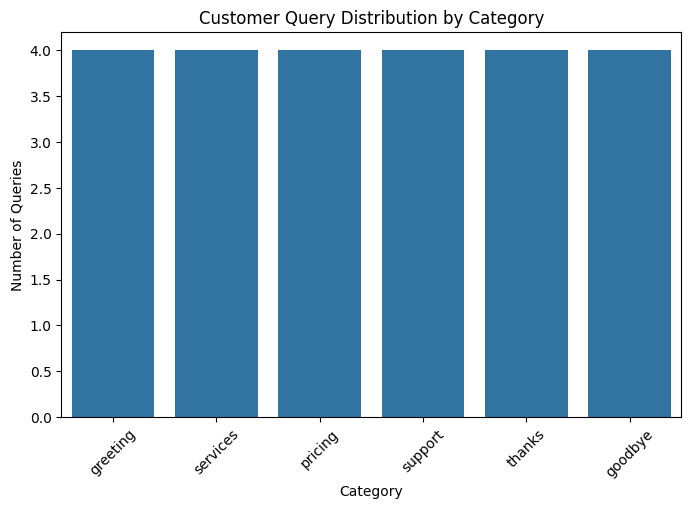

In [ ]:
# ============================================
# STEP 12: DATA ANALYSIS VISUALIZATION
# Query Distribution by Category
# ============================================

# Count the number of queries in each category
category_counts = data['category'].value_counts()

# Display the counts
print("Number of queries in each category:")
print(category_counts)

# Create a bar chart
plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.xlabel("Category")
plt.ylabel("Number of Queries")
plt.title("Customer Query Distribution by Category")

plt.xticks(rotation=45)

plt.show()

Query Length Statistics:
count    24.000000
mean      3.291667
std       1.545798
min       1.000000
25%       2.000000
50%       4.000000
75%       4.000000
max       6.000000
Name: query_length, dtype: float64

Query Length Examples:
                           query  query_length
0                          Hello             1
1                             Hi             1
2                   Good morning             2
3                      Hey there             2
4  What services do you provide?             5
5   What services are available?             4
6    Tell me about your services             5
7     What can you help me with?             6
8             What is the price?             4
9         How much does it cost?             5


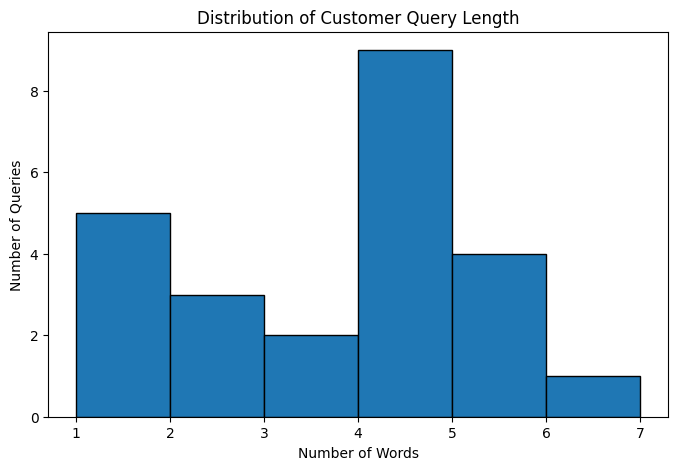

In [ ]:
# ============================================
# STEP 13: QUERY LENGTH ANALYSIS
# ============================================

# Calculate the number of words in each query
data['query_length'] = data['cleaned_query'].apply(
    lambda x: len(x.split())
)

# Display query length information
print("Query Length Statistics:")
print(data['query_length'].describe())

# Display some queries with their lengths
print("\nQuery Length Examples:")
print(data[['query', 'query_length']].head(10))

# Create a histogram
plt.figure(figsize=(8, 5))

plt.hist(
    data['query_length'],
    bins=range(
        data['query_length'].min(),
        data['query_length'].max() + 2
    ),
    edgecolor='black'
)

plt.xlabel("Number of Words")
plt.ylabel("Number of Queries")
plt.title("Distribution of Customer Query Length")

plt.show()

Average Query Length by Category:
category
goodbye     2.25
greeting    1.50
pricing     4.25
services    5.00
support     3.75
thanks      3.00
Name: query_length, dtype: float64


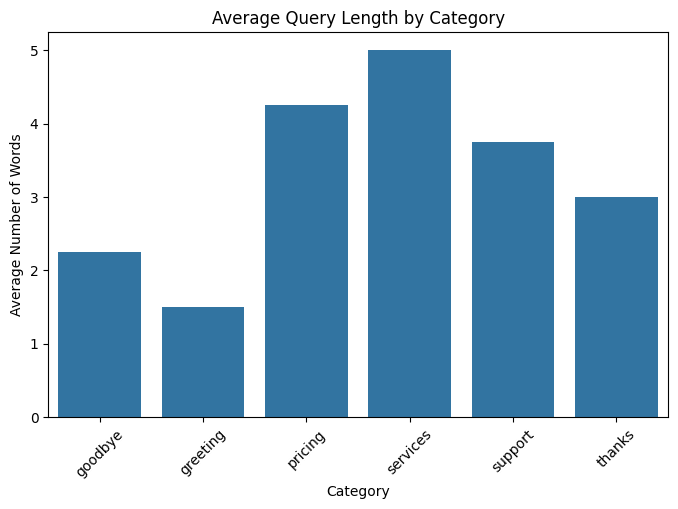

In [ ]:

# ============================================
# STEP 14: CATEGORY-WISE QUERY LENGTH ANALYSIS
# ============================================

# Calculate the average query length for each category
average_length = data.groupby('category')['query_length'].mean()

# Display the results
print("Average Query Length by Category:")
print(average_length)

# Create a bar chart
plt.figure(figsize=(8, 5))

sns.barplot(
    x=average_length.index,
    y=average_length.values
)

plt.xlabel("Category")
plt.ylabel("Average Number of Words")
plt.title("Average Query Length by Category")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ============================================
# STEP 15: WORD FREQUENCY ANALYSIS
# ============================================

from collections import Counter

# Combine all cleaned customer queries into one text
all_text = " ".join(data['cleaned_query'])

# Split the text into individual words
words = all_text.split()

# Count how many times each word appears
word_counts = Counter(words)

# Display the 10 most common words
print("Top 10 Most Frequent Words:")
print(word_counts.most_common(10))

Top 10 Most Frequent Words:
[('you', 6), ('what', 5), ('help', 5), ('me', 4), ('your', 4), ('i', 4), ('services', 3), ('are', 2), ('tell', 2), ('can', 2)]


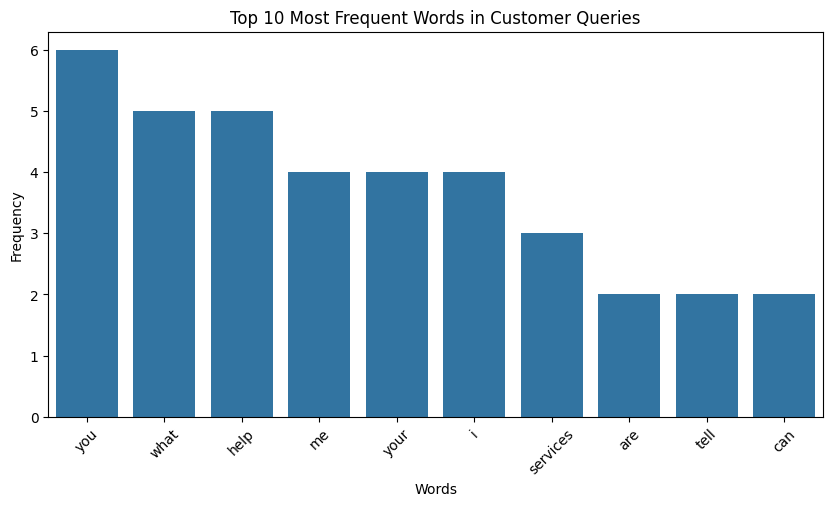

In [ ]:
# Get the 10 most frequent words
top_words = word_counts.most_common(10)

# Separate words and their frequencies
words_list = [item[0] for item in top_words]
frequency_list = [item[1] for item in top_words]

# Create bar chart
plt.figure(figsize=(10, 5))

sns.barplot(
    x=words_list,
    y=frequency_list
)

plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Words in Customer Queries")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# ============================================
# STEP 16: MODEL PERFORMANCE ANALYSIS
# ============================================

from sklearn.metrics import accuracy_score, confusion_matrix

# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy Percentage:", round(accuracy * 100, 2), "%")

# Create confusion matrix
categories = sorted(data['category'].unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=categories
)

# Display confusion matrix
print("\nConfusion Matrix:")
print(pd.DataFrame(
    cm,
    index=categories,
    columns=categories
))

Model Accuracy: 0.6666666666666666
Model Accuracy Percentage: 66.67 %

Confusion Matrix:
          goodbye  greeting  pricing  services  support  thanks
goodbye         0         0        0         0        0       1
greeting        0         1        0         0        0       0
pricing         0         0        1         0        0       0
services        0         0        0         1        0       0
support         0         0        0         0        1       0
thanks          0         0        0         0        1       0


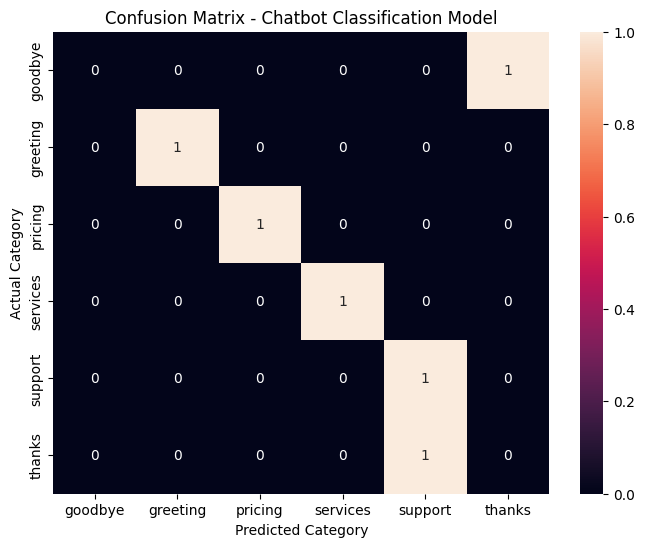

In [ ]:
# ============================================
# CONFUSION MATRIX HEATMAP
# ============================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=categories,
    yticklabels=categories
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix - Chatbot Classification Model")

plt.show()

In [ ]:
# ============================================
# STEP 17: TEST CHATBOT WITH NEW QUERIES
# ============================================

# New queries for testing
new_questions = [
    "Hi there",
    "Can you tell me about your services?",
    "How much will I have to pay?",
    "I am facing an issue",
    "Thanks for helping me",
    "See you later",
    "What is the weather today?"
]

# Test each query
for question in new_questions:

    response = chatbot_response_final(question)

    print("User:", question)
    print("Chatbot:", response)
    print("-" * 60)

User: Hi there
Chatbot: Hi! How can I help you?
------------------------------------------------------------
User: Can you tell me about your services?
Chatbot: We provide customer-focused services.
------------------------------------------------------------
User: How much will I have to pay?
Chatbot: Please contact us for detailed pricing information.
------------------------------------------------------------
User: I am facing an issue
Chatbot: Sorry, I don't understand your question. Could you please rephrase it?
------------------------------------------------------------
User: Thanks for helping me
Chatbot: You're welcome! Happy to help.
------------------------------------------------------------
User: See you later
Chatbot: You're very welcome!
------------------------------------------------------------
User: What is the weather today?
Chatbot: Sorry, I can only answer questions about our services, pricing, support, and general customer queries.
------------------------------

In [ ]:
# ============================================
# STEP 18: FINAL CHATBOT PERFORMANCE ANALYSIS
# ============================================

# New test questions
test_questions = [
    "Hi there",
    "Can you tell me about your services?",
    "How much will I have to pay?",
    "I am facing an issue",
    "Thanks for helping me",
    "See you later"
]

# Expected categories
expected_categories = [
    "greeting",
    "services",
    "pricing",
    "support",
    "thanks",
    "goodbye"
]

# Get predictions from the ML model
predicted_categories = []

for question in test_questions:

    cleaned_input = preprocess_text(question)

    input_vector = vectorizer.transform([cleaned_input])

    prediction = model.predict(input_vector)[0]

    predicted_categories.append(prediction)

# Create comparison table
final_comparison = pd.DataFrame({
    "Query": test_questions,
    "Expected Category": expected_categories,
    "Predicted Category": predicted_categories
})

# Check whether each prediction is correct
final_comparison["Correct"] = (
    final_comparison["Expected Category"]
    == final_comparison["Predicted Category"]
)

# Calculate accuracy
final_accuracy = final_comparison["Correct"].mean()

print("Final New-Query Test Results:")
display(final_comparison)

print(
    "\nNew-Query Test Accuracy:",
    round(final_accuracy * 100, 2),
    "%"
)

Final New-Query Test Results:


,Query,Expected Category,Predicted Category,Correct
0,Hi there,greeting,greeting,True
1,Can you tell me about your services?,services,services,True
2,How much will I have to pay?,pricing,pricing,True
3,I am facing an issue,support,greeting,False
4,Thanks for helping me,thanks,thanks,True
5,See you later,goodbye,thanks,False



New-Query Test Accuracy: 66.67 %


In [ ]:
# ============================================
# STEP 19: FINAL PROJECT RESULTS
# ============================================

print("==============================================")
print(" CUSTOMER QUERY ANALYSIS AND NLP CHATBOT")
print("             FINAL RESULTS")
print("==============================================")

# Dataset information
print("\n1. DATASET")
print("Total queries:", len(data))
print("Number of categories:", data['category'].nunique())

# Category information
print("\n2. CATEGORIES")
print(data['category'].unique())

# Query length
print("\n3. QUERY LENGTH")
print("Average query length:",
      round(data['query_length'].mean(), 2), "words")

print("Minimum query length:",
      data['query_length'].min(), "word")

print("Maximum query length:",
      data['query_length'].max(), "words")

# Model performance
print("\n4. MACHINE LEARNING MODEL")
print("Algorithm: Logistic Regression")
print("Text representation: TF-IDF")
print("Test Accuracy:",
      round(accuracy * 100, 2), "%")

# Final new-query testing
print("\n5. NEW QUERY TESTING")
print("New-query test accuracy:",
      round(final_accuracy * 100, 2), "%")

# Final conclusion
print("\n6. CONCLUSION")
print(
    "The project successfully developed a simple customer-support "
    "chatbot using NLP, TF-IDF and Logistic Regression. "
    "The chatbot can classify customer queries into predefined "
    "categories and generate appropriate responses."
)

print("\n==============================================")
print("             PROJECT COMPLETED")
print("==============================================")

 CUSTOMER QUERY ANALYSIS AND NLP CHATBOT
             FINAL RESULTS

1. DATASET
Total queries: 24
Number of categories: 6

2. CATEGORIES
['greeting' 'services' 'pricing' 'support' 'thanks' 'goodbye']

3. QUERY LENGTH
Average query length: 3.29 words
Minimum query length: 1 word
Maximum query length: 6 words

4. MACHINE LEARNING MODEL
Algorithm: Logistic Regression
Text representation: TF-IDF
Test Accuracy: 66.67 %

5. NEW QUERY TESTING
New-query test accuracy: 66.67 %

6. CONCLUSION
The project successfully developed a simple customer-support chatbot using NLP, TF-IDF and Logistic Regression. The chatbot can classify customer queries into predefined categories and generate appropriate responses.

             PROJECT COMPLETED
